# NumPy · pandas · matplotlib

**Rahnema College ML Bootcamp 1405** 

---

## The one message of these two hours

> **Don't write loops.**

The job of this session is to move the maths you have been learning off the
whiteboard and into code. It is not a guided tour of the pandas API.

## What do these three libraries actually give us?

Python itself was not built for numbers. A `list` of a million integers is a
million separate objects in memory. These libraries solve three different
layers of that same problem:

| Library | Data structure | What it gives you | In one phrase |
|---|---|---|---|
| **NumPy** | `ndarray` — one contiguous block of memory, one dtype | vectorised maths, linear algebra, random numbers | *the unit of computation* |
| **pandas** | `DataFrame` — labelled columns, each one a NumPy array | file I/O, mixed types, missing values, `groupby`, `merge` | *the unit of real data* |
| **matplotlib** | `Figure` / `Axes` | full control over every pixel of a plot | *our eyes* |
| **seaborn** | a layer on top of matplotlib | statistical plots straight from a DataFrame, in one line | *our eyes, in a hurry* |

One architectural point worth holding on to: pandas is built **on** NumPy, and
seaborn **on** matplotlib. These are not four independent things — they are two
pillars, each with a convenience layer. Whenever pandas gets in your way, call
`df.to_numpy()` and drop down a level.

### Setup

Run this first. If it fails, you skipped `00_check_setup.ipynb`.

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make `from bootcamp import ...` work whether jupyter was started in the repo
# root or inside notebooks/. Also gives us DATA for the pandas block later.
ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
DATA = ROOT / "data"

# All of this ends up on a projector: bigger text, fewer distracting gridlines.
plt.rcParams.update({
    "figure.figsize": (7.5, 4.2),
    "figure.dpi": 110,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.spines.top": False,     # the top and right box edges carry no
    "axes.spines.right": False,   # information, so drop them
})
sns.set_theme(style="whitegrid", palette="deep", rc=plt.rcParams)

# One generator, one seed, for the whole notebook -- so your numbers match mine.
# More on why `default_rng` and not `np.random.seed` in block 3.
rng = np.random.default_rng(seed=1405) # Random Number Generator

print("python  ", sys.version.split()[0])
for mod in (np, pd, plt.matplotlib, sns):
    print(f"{mod.__name__:8}", mod.__version__)

python   3.9.6
numpy    2.0.2
pandas   2.3.3
matplotlib 3.9.4
seaborn  0.13.2


---

# Block 0 — Why bother?

Two reasons. Everyone gives you the first one; the second one matters more.

### Reason one: speed

The same job, once with a Python loop and once vectorised.

In [2]:
xs = list(range(1_000_000))      # a million python int objects
a = np.arange(1_000_000)         # a million int64 values in one memory block

# `%timeit -o` returns the result object instead of only printing it, and -q
# keeps it quiet so we can format the comparison ourselves.
t_py = %timeit -o -q sum(x * x for x in xs)
t_np = %timeit -o -q (a * a).sum()

print(f"python loop : {t_py.average * 1e3:8.2f} ms")
print(f"numpy       : {t_np.average * 1e3:8.2f} ms")
print(f"speedup     : {t_py.average / t_np.average:8.0f}x")

python loop :    24.51 ms
numpy       :     0.35 ms
speedup     :       71x


Why such a gap? The Python loop treats every number as an object: for each
multiplication it has to check the type, allocate a new object and update a
reference count. NumPy hands one contiguous block of memory with a known dtype
to compiled C code, which then walks that memory with no overhead at all (and
uses your CPU's SIMD instructions while it is there).

Write that speedup factor on the whiteboard and leave it there for the rest of
the session.

### Reason two, the bigger one: your code starts to look like the maths

This gets said less often, but it will affect your life more. "The distance
from every point to every other point" is one line in mathematical notation:
$D_{ij} = \lVert p_i - p_j \rVert_2$. In NumPy it is also one line. With loops
it is seven.

Code that looks like its formula is code you can still read three weeks later.

In [3]:
P = rng.normal(size=(500, 2))    # 500 points in 2-D

# The literal translation of the definition: two loops, one distance each.
D_loop = np.empty((len(P), len(P)))
for i in range(len(P)):
    for j in range(len(P)):
        D_loop[i, j] = np.sqrt(((P[i] - P[j]) ** 2).sum())

# The same thing, vectorised. Follow the shapes, they are the whole trick:
#   P[:, None, :] -> (500,   1, 2)   every point, as a column
#   P[None, :, :] -> (  1, 500, 2)   every point, as a row
#   difference    -> (500, 500, 2)   broadcasting paired them all up for us
#   .sum(axis=-1) -> (500, 500)      collapse the coordinate axis
D_vec = np.sqrt(((P[:, None, :] - P[None, :, :]) ** 2).sum(axis=-1))

print("shape:", D_vec.shape, "| identical to the loop:", np.allclose(D_loop, D_vec))

shape: (500, 500) | identical to the loop: True


---

# Block 1 — NumPy on one page

This block is **reference**, not lecture. The figure below is everything you
need on 90% of working days. I will walk through it quickly; the cells after it
make the same concepts runnable so you can poke at them.

Take one rule away from this block: **print `shape` after every operation.**
90% of NumPy bugs come from your array not being the shape you thought it was.

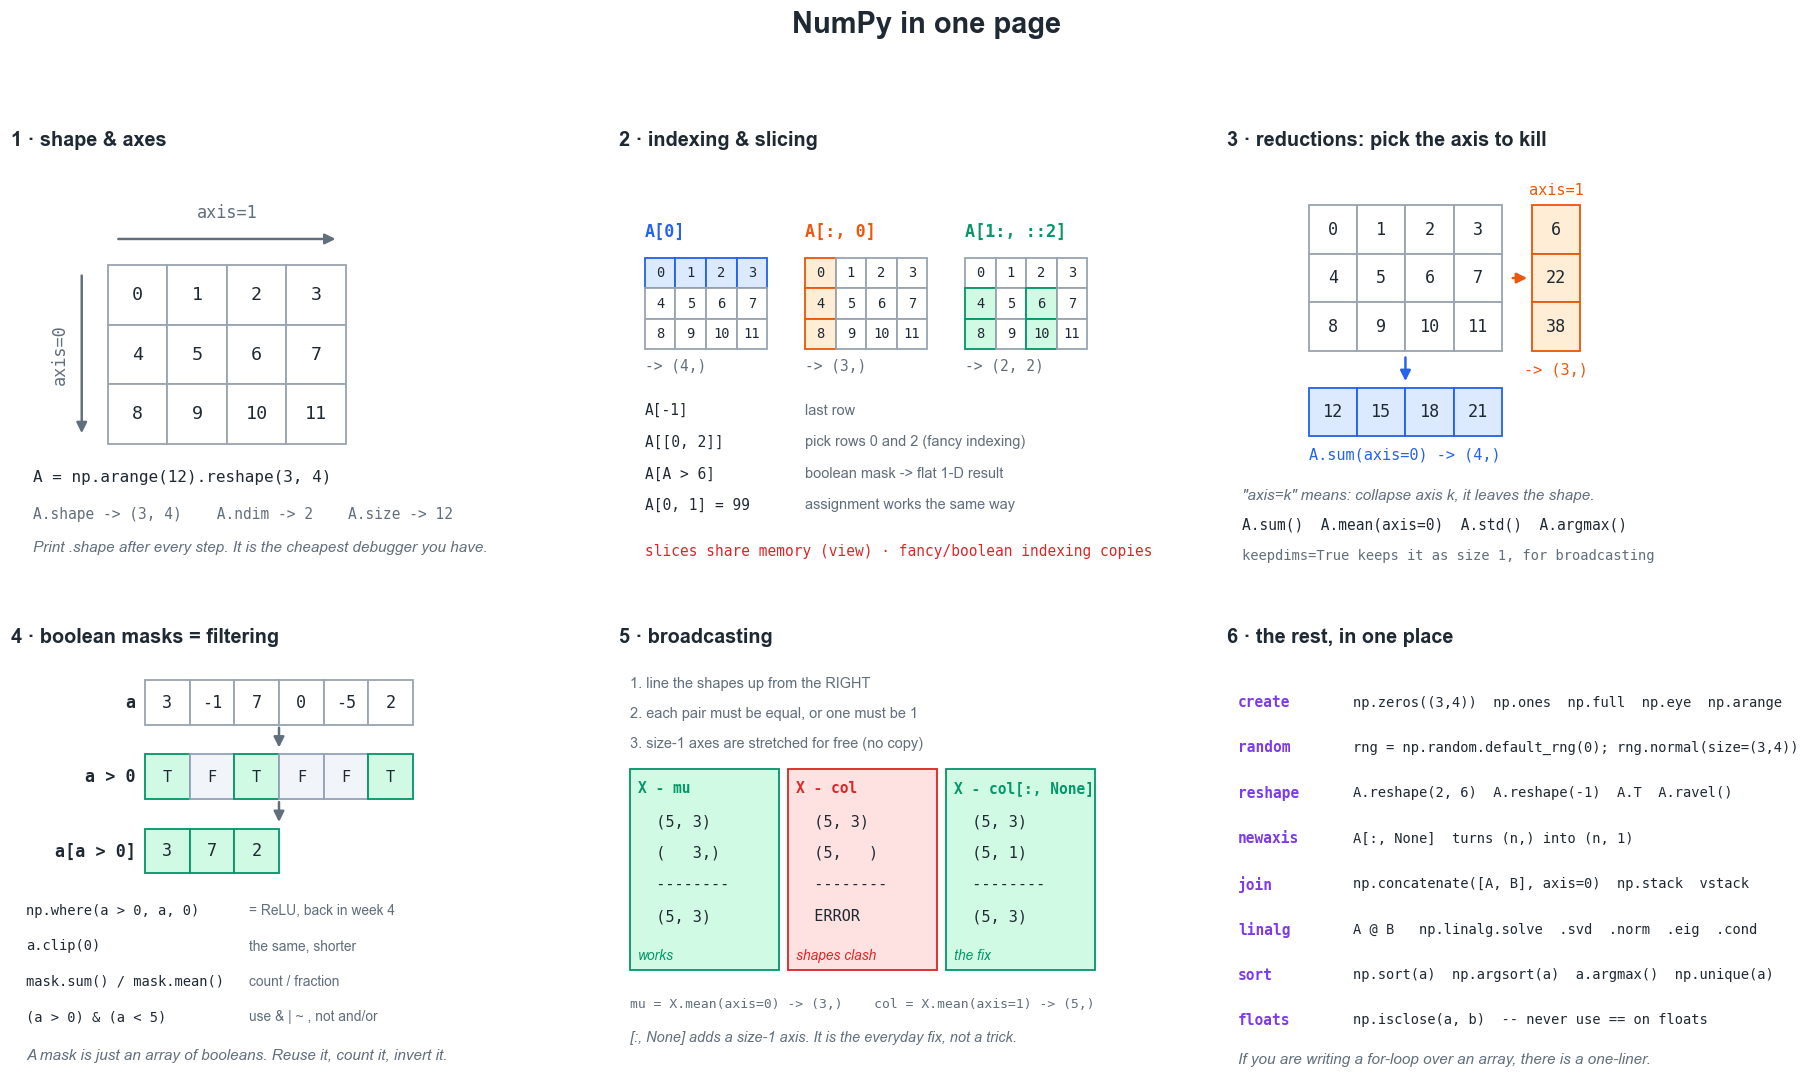

In [4]:
from bootcamp import numpy_cheatsheet, pandas_cheatsheet

# Drawn with matplotlib in bootcamp/cheatsheets.py, so it lives in git and
# scales to any projector. Also saved as assets/numpy_cheatsheet.png to print.
numpy_cheatsheet();

### 1.1 Shape and axes

In [5]:
A = np.arange(12).reshape(3, 4)

print(A)
print("shape", A.shape, "| ndim", A.ndim, "| dtype", A.dtype, "| size", A.size)

# "axis=k" means: collapse axis k -- it disappears from the resulting shape.
print("sum()        ->", A.sum())                              # everything -> scalar
print("sum(axis=0)  ->", A.sum(axis=0), A.sum(axis=0).shape)    # kill the rows
print("sum(axis=1)  ->", A.sum(axis=1), A.sum(axis=1).shape)    # kill the columns

# keepdims leaves the axis in place with size 1. You want this whenever the
# result has to broadcast back against the original array -- see 1.4.
print("keepdims     ->", A.mean(axis=1, keepdims=True).shape)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
shape (3, 4) | ndim 2 | dtype int64 | size 12
sum()        -> 66
sum(axis=0)  -> [12 15 18 21] (4,)
sum(axis=1)  -> [ 6 22 38] (3,)
keepdims     -> (3, 1)


### 1.2 Indexing and slicing

In [6]:
# Comma-separated indices, one per axis. A slice `start:stop:step` per axis too.
print("A[0]        ", A[0], "  -> first row, shape", A[0].shape)
print("A[:, 0]     ", A[:, 0], "  -> first column, shape", A[:, 0].shape)
print("A[1:, ::2]  ", A[1:, ::2].tolist(), "-> from row 1, every 2nd column")
print("A[-1]       ", A[-1], "  -> last row, negative counts from the end")

# Passing a *list* of indices is "fancy indexing": pick arbitrary rows in any
# order, with repeats allowed. Note this returns a copy, unlike a slice.
print("A[[0, 2]]   ", A[[0, 2]].tolist(), "-> fancy indexing: rows 0 and 2")

A[0]         [0 1 2 3]   -> first row, shape (4,)
A[:, 0]      [0 4 8]   -> first column, shape (3,)
A[1:, ::2]   [[4, 6], [8, 10]] -> from row 1, every 2nd column
A[-1]        [ 8  9 10 11]   -> last row, negative counts from the end
A[[0, 2]]    [[0, 1, 2, 3], [8, 9, 10, 11]] -> fancy indexing: rows 0 and 2


**Trap one: view versus copy.** A slice *shares* memory with the original
array; fancy or boolean indexing makes a *copy*. This difference is why an
array you thought was untouched has quietly changed.

In [7]:
B = np.arange(6)

view = B[:3]        # a slice -> a window onto B's memory, no data copied
copy = B[B < 3]     # boolean indexing -> a brand new array

view[0] = 999       # writes through to B
copy[1] = 777       # writes only to `copy`

print("B    ", B, "  <- changed through the view")
print("view ", view)
print("copy ", copy, "  <- B did not notice this one")

# np.shares_memory is how you settle the argument instead of guessing.
print("shares memory with B:", np.shares_memory(B, view), np.shares_memory(B, copy))

B     [999   1   2   3   4   5]   <- changed through the view
view  [999   1   2]
copy  [  0 777   2]   <- B did not notice this one
shares memory with B: True False


### 1.3 Boolean masks are how you filter

In [8]:
a = np.array([3, -1, 7, 0, -5, 2])

# A comparison on an array returns an array of booleans, same shape. That
# array is the "mask", and it is a first-class value you can reuse.
mask = a > 0
print("a        ", a)
print("a > 0    ", mask)
print("a[a > 0] ", a[mask], "  <- 1-D copy of the passing elements")

# Because True is 1: .sum() answers "how many", .mean() answers "what fraction".
print("how many positive:", mask.sum(), "| what fraction:", mask.mean().round(2))

# np.where is an element-wise if/else: where(condition, value_if, value_else).
# This particular one has a famous name.
print("relu(a)  ", np.where(a > 0, a, 0), " <- you meet this again in week 4")
print("clip(0)  ", a.clip(0), " <- same thing, shorter")

# Combine conditions with & | ~ and wrap each one in parentheses. Python's
# `and`/`or`/`not` raise on arrays, because they want a single True/False.
print("0 < a < 5:", a[(a > 0) & (a < 5)])

a         [ 3 -1  7  0 -5  2]
a > 0     [ True False  True False False  True]
a[a > 0]  [3 7 2]   <- 1-D copy of the passing elements
how many positive: 3 | what fraction: 0.5
relu(a)   [3 0 7 0 0 2]  <- you meet this again in week 4
clip(0)   [3 0 7 0 0 2]  <- same thing, shorter
0 < a < 5: [3 2]


### 1.4 Broadcasting

The rule in three lines: line the shapes up **from the right**; each pair of
dimensions must be equal or one of them must be 1; size-1 dimensions get
stretched (with no memory copy).

We trigger the error below on purpose, because it is the one you will hit for
real next week.

In [9]:
X = rng.normal(size=(5, 3))
X

array([[ 1.02915646,  1.46359395,  1.12863562],
       [ 0.58495897, -1.30908306,  0.65745081],
       [-1.10609223, -1.71189872,  0.12021   ],
       [-0.66388323,  0.43145632, -0.74125082],
       [ 0.7279953 ,  0.0048034 , -2.37321449]])

In [10]:
mu = X.mean(axis=0)        # (3,)  -- one mean per column
mu

array([ 0.11442705, -0.22422562, -0.24163378])

In [11]:
mu + 1

array([1.11442705, 0.77577438, 0.75836622])

In [12]:

col = X.mean(axis=1)       # (5,)  -- one mean per row

print("X", X.shape, "| mu", mu.shape, "| col", col.shape)

# (5, 3) against (3,): line them up from the right, 3 == 3, then the row of
# means is reused for all 5 rows. This is how you centre a matrix.
print("X - mu          ->", (X - mu).shape)

# (5, 3) against (5,): lined up from the right that reads 3 against 5. No.
# NumPy will not guess that you meant the *other* axis.
try:
    X - col
except ValueError as err:
    print("X - col         -> ValueError:", err)

# Say which axis you meant and it works. [:, None] inserts a size-1 axis,
# turning (5,) into (5, 1). Everyday tool, not a trick.
print("X - col[:, None] ->", (X - col[:, None]).shape)

X (5, 3) | mu (3,) | col (5,)
X - mu          -> (5, 3)
X - col         -> ValueError: operands could not be broadcast together with shapes (5,3) (5,) 
X - col[:, None] -> (5, 3)


**Trap two: comparing floats.** `float` is binary and cannot represent some
decimal fractions exactly. Never write `==` on floats.

In [13]:
print("0.1 + 0.2 == 0.3        ->", 0.1 + 0.2 == 0.3)
print("0.1 + 0.2                ->", f"{0.1 + 0.2:.20f}")   # look at the tail

# isclose compares with a tolerance; allclose does the same for whole arrays.
print("np.isclose(0.1+0.2, 0.3) ->", np.isclose(0.1 + 0.2, 0.3))

0.1 + 0.2 == 0.3        -> False
0.1 + 0.2                -> 0.30000000000000004441
np.isclose(0.1+0.2, 0.3) -> True


### Exercise 1 — vectorise this loop

`row_normalise_loop` scales each row so that it sums to 1. Write the same thing
with no loops at all.

Hint: what shape is `X.sum(axis=1)`? What shape does it *need* to be to divide
into `X`?

In [14]:
def row_normalise_loop(X):
    """Scale every row so that it sums to 1 -- the slow, literal way."""
    out = np.empty_like(X, dtype=float)
    for i in range(X.shape[0]):
        total = 0.0
        for j in range(X.shape[1]):        # first pass: add the row up
            total += X[i, j]
        for j in range(X.shape[1]):        # second pass: divide it through
            out[i, j] = X[i, j] / total
    return out


def row_normalise(X):
    """Same result, no loops."""
    # TODO: one line. Watch the shapes -- see block 1.4.
    raise NotImplementedError


M = rng.random((400, 50))
expected = row_normalise_loop(M)

# Wrapped in try/except so the notebook still runs top-to-bottom before you
# have filled the TODO in.
try:
    got = row_normalise(M)
except NotImplementedError:
    print("row_normalise is still a TODO -- your turn.")
else:
    print("matches the loop:", np.allclose(got, expected))
    t_loop = %timeit -o -q row_normalise_loop(M)
    t_vec = %timeit -o -q row_normalise(M)
    print(f"speedup: {t_loop.average / t_vec.average:.0f}x")

row_normalise is still a TODO -- your turn.


---

# Block 2 — From maths to code: writing PCA ourselves

The point of this block is not to teach PCA; Shamim did that this morning. The
point is this:

> **Every algorithm you meet in the next nine weeks has a mathematical core
> that is a handful of lines, and that core can be written in NumPy.**

Do this once yourself and `model.fit(X, y)` never looks like magic again. You
will want exactly that feeling when you get to backprop in week 4.


## 2.1 PCA, straight from the definition

PCA is four steps and each step is one line of code. Given data
$X \in \mathbb{R}^{n \times d}$:

**1. Centre.** $\tilde X = X - \bar{x}$, where $\bar{x}$ is the column mean.
Skip this step and your first component just finds the direction of the
*centre* of the data instead of the direction of its *spread*.

**2. SVD.** $\tilde X = U S V^{\top}$. The columns of $V$ (i.e. the rows of
`Vt`) are the principal directions; $S$ holds the singular values.

**3. Project.** $Z = \tilde X V_k$, where $V_k$ is the first $k$ directions.
$Z$ is our data expressed in the new coordinates.

**4. Explained variance.** $\mathrm{EVR}_i = s_i^2 / \sum_j s_j^2$.

Why is SVD the same thing as PCA? Because the sample covariance matrix is

$$C = \frac{1}{n-1}\tilde X^{\top}\tilde X = \frac{1}{n-1} V S^{\top}U^{\top}U S V^{\top} = V \frac{S^2}{n-1} V^{\top}$$

so $V$ holds the eigenvectors of $C$ and $s_i^2/(n-1)$ are its eigenvalues.
"Directions that maximise variance" and "right singular vectors" are the same
set of vectors. We take the SVD directly because forming $C$ explicitly and then
decomposing it is numerically worse: squaring the matrix squares its condition
number, and you lose precision for nothing.

In [15]:
from sklearn.datasets import load_iris

# Iris ships with sklearn. 150 flowers, 4
# measurements each, 3 species. `y` is only used for colouring the plot --
# PCA itself never sees it.
iris = load_iris(as_frame=True)

iris.data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [16]:
X = iris.data.to_numpy()                  # (150, 4)
y = iris.target.to_numpy()
species = np.array(iris.target_names)[y]  # 'setosa' / 'versicolor' / 'virginica'

print("X", X.shape, "| features:", list(iris.feature_names))

X (150, 4) | features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [17]:
# --- PCA in four lines -------------------------------------------------
Xc = X - X.mean(axis=0)                              # 1. centre each column
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)    # 2. SVD (economy size)
Z = Xc @ Vt[:2].T                                    # 3. project onto 2 axes
evr = S ** 2 / (S ** 2).sum()                        # 4. explained variance
# ----------------------------------------------------------------------

# full_matrices=False keeps U at (150, 4) instead of (150, 150). We never need
# the other 146 columns and they would cost 170x the memory.
print("Vt", Vt.shape, "| S", S.shape, "| Z", Z.shape)
print("explained variance ratio:", evr.round(4))
print(f"first two components keep {evr[:2].sum():.1%} of the variance")

Vt (4, 4) | S (4,) | Z (150, 2)
explained variance ratio: [0.9246 0.0531 0.0171 0.0052]
first two components keep 97.8% of the variance


Four lines. Now let's look at it.

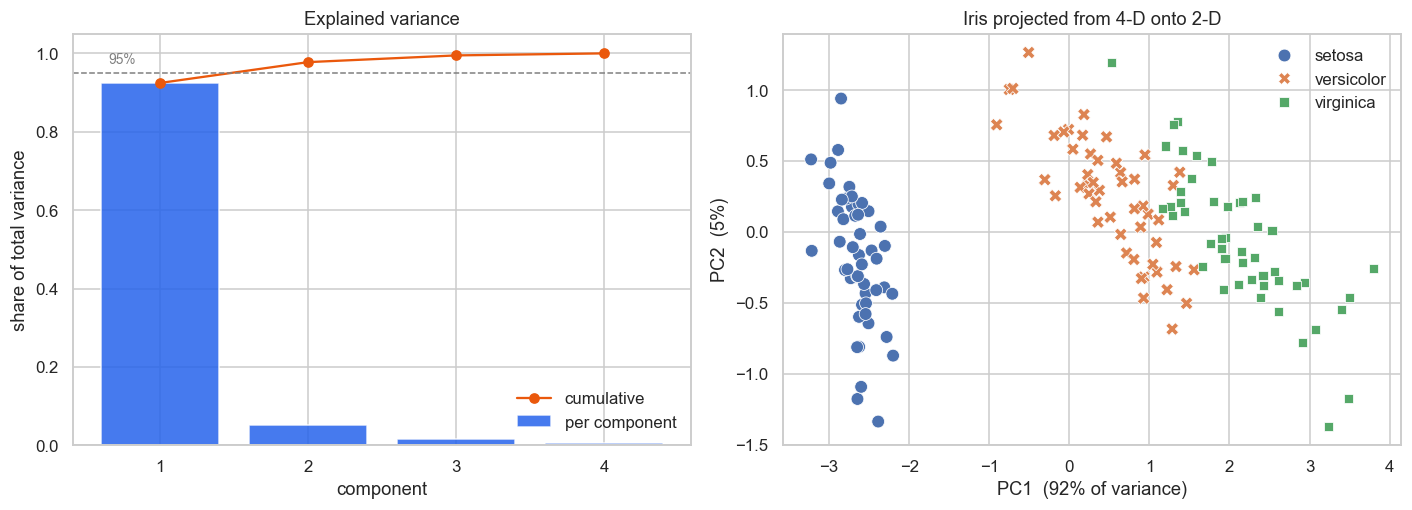

In [18]:
fig, (ax_var, ax_proj) = plt.subplots(1, 2, figsize=(13, 4.8))

# Left: how much variance each component carries (this is a "scree plot").
comps = np.arange(1, len(evr) + 1)
ax_var.bar(comps, evr, color="#2563eb", alpha=0.85, label="per component")
ax_var.plot(comps, evr.cumsum(), "o-", color="#ea580c", label="cumulative")
ax_var.axhline(0.95, ls="--", lw=1, color="grey")     # a common cut-off
ax_var.text(0.65, 0.965, "95%", ha="left", va="bottom", color="grey", fontsize=9)
ax_var.set(xlabel="component", ylabel="share of total variance",
           title="Explained variance", xticks=comps, ylim=(0, 1.05))
ax_var.legend(frameon=False)

# Right: the 150x4 dataset drawn on the two directions we just computed.
# seaborn's `hue`/`style` split by species in one call; the underlying object
# is still a matplotlib Axes, which is why ax_proj.set() works afterwards.
sns.scatterplot(x=Z[:, 0], y=Z[:, 1], hue=species, style=species, s=70,
                ax=ax_proj, edgecolor="white", linewidth=0.5)
ax_proj.set(xlabel=f"PC1  ({evr[0]:.0%} of variance)",
            ylabel=f"PC2  ({evr[1]:.0%})",
            title="Iris projected from 4-D onto 2-D")
ax_proj.legend(title=None, frameon=False)

fig.tight_layout()

We took four dimensions down to two, kept about 98% of the variance, and the
classes are still separated. We never looked at `y` — PCA is unsupervised; the
colours are only there so that *we* can see what happened.

One practical point people get wrong: PCA is sensitive to column scale. If one
column is in toman and another is a count, the toman column swallows PC1 purely
because its numbers are bigger. All four iris columns are centimetres so we are
fine here, but on real data you almost always standardise first
(`StandardScaler`).

## 2.2 sklearn has this too

Now that you have written it, here are the two ready-made lines — and here is
the proof they agree. The sign of each component is arbitrary (if $v$ is a
principal direction then so is $-v$), so we compare absolute values.

In [19]:
from sklearn.decomposition import PCA

# fit_transform = fit (find the directions) then transform (project onto them),
# which is steps 1-3 of our four. Note it centres the data for us.
Z_sk = PCA(n_components=2).fit_transform(X)

The lesson of that comparison: **the library is not magic.** Everything you
call in `sklearn` has a mathematical core that somebody wrote. What it adds
over our version is edge-case handling, speed and tests. But it is the same
four lines.

From here on in the bootcamp, every time you meet an algorithm, ask yourself
once: "what is its mathematical core?" If you can answer, you understand it.

## 2.3 Dimensionality reduction beyond PCA — for your own reading

PCA is **linear**: all it can do is rotate your data and project it onto a
subspace. If the structure of your data lies on a curved manifold (a spiral,
say), PCA cannot see it. Two non-linear methods you will run into often:

**t-SNE** (2008) — preserves *local* distances. Excellent for seeing clusters.
- Distances *between* clusters and cluster *sizes* in a t-SNE plot are
  **meaningless**.
- The `perplexity` parameter changes the answer; always try a few values.
- It has no `transform`: you cannot map new data into a learned embedding.

**UMAP** (2018) — similar idea, different mathematical footing (topology). It
is faster, preserves global structure better, and does have `transform`. Not in
sklearn: `pip install umap-learn`.

**Practical rule:** t-SNE and UMAP are tools for *looking*, not for
*preprocessing*. For building features to feed a model, PCA — linear, stable,
and applicable to new data — is the safer choice.

Worth reading:
- [How to Use t-SNE Effectively](https://distill.pub/2016/misread-tsne/) — the best thing written on this, and interactive
- [UMAP documentation](https://umap-learn.readthedocs.io/en/latest/how_umap_works.html)
- [sklearn's manifold learning guide](https://scikit-learn.org/stable/modules/manifold.html)

The next cell is optional; we will not have time for it in the session.

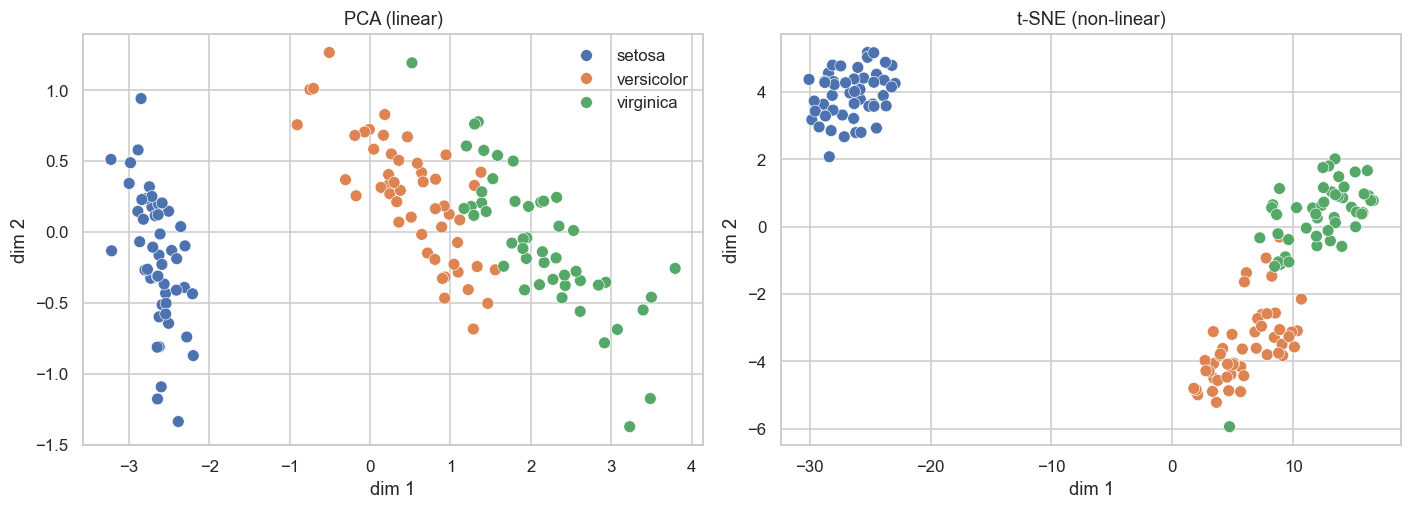

In [20]:
from sklearn.manifold import TSNE

# t-SNE starts from an initial layout and improves it iteratively. Instead of
# letting it compute its own, hand it the PCA projection we already have -- it
# converges to a more stable answer. The 1e-4 scaling is what sklearn's docs
# recommend for a custom init.
tsne_init = (Z / Z[:, 0].std()) * 1e-4

# 150 points, so this is instant. On 50k points it is emphatically not.
Z_tsne = TSNE(n_components=2, perplexity=30, init=tsne_init,
              random_state=0).fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, emb, name in [(axes[0], Z, "PCA (linear)"),
                      (axes[1], Z_tsne, "t-SNE (non-linear)")]:
    sns.scatterplot(x=emb[:, 0], y=emb[:, 1], hue=species, s=60, ax=ax,
                    edgecolor="white", linewidth=0.4, legend=(ax is axes[0]))
    ax.set(title=name, xlabel="dim 1", ylabel="dim 2")
axes[0].legend(title=None, frameon=False)
fig.tight_layout()

# Note how t-SNE separates the two overlapping species more aggressively --
# and how the distance between the clusters means nothing at all.

---

# Block 3 — Probability, as simulation

This morning you proved these theorems on paper. Now we watch them **happen**.
That is worth doing for two reasons: a theorem turns from "a formula" into "a
behaviour" in your head, and simulation is a genuine working tool — when you
cannot solve a problem analytically, you simulate it.

## First: generating random numbers, properly

```python
rng = np.random.default_rng(1405)   # do this
np.random.seed(1405)                # not this (legacy global state)
```

`default_rng` has been NumPy's recommended interface since 1.17. It gives you
an independent object, so two parts of your code cannot accidentally corrupt
each other's state.

And the seed — the `1405` at the top of this notebook — means your numbers and
mine are identical. That is the foundation of **reproducibility**: Mobin
Nik-khesal spends a whole session on it in week 9, but start the habit today. A
result you cannot reproduce is not a result.

⚠️ One caveat: a seed is for *reproducibility*, not for making your results
*look good*. If you find yourself changing the seed until the plot is prettier,
the problem is somewhere else.

## 3.1 The law of large numbers

### Theory

Let $X_1, X_2, \dots$ be independent and identically distributed with finite
$\mathbb{E}[X] = \mu$. Define the sample mean

$$\bar{X}_n = \frac{1}{n}\sum_{i=1}^{n} X_i$$

The law of large numbers says $\bar{X}_n \to \mu$. It comes in two versions:

- **Weak (WLLN):** convergence in probability. For every $\varepsilon > 0$,
  $\;\mathbb{P}\big(|\bar{X}_n - \mu| > \varepsilon\big) \to 0$.
- **Strong (SLLN):** almost sure convergence,
  $\;\mathbb{P}\big(\lim_{n\to\infty} \bar{X}_n = \mu\big) = 1$.

Proving the weak version takes three lines with Chebyshev's inequality: since
$\mathrm{Var}(\bar{X}_n) = \sigma^2/n$, we get
$\mathbb{P}(|\bar{X}_n - \mu| > \varepsilon) \le \sigma^2/(n\varepsilon^2) \to 0$.

### What the law does **not** say

This is the important part, and the source of one of the most common failures
of intuition:

1. **Nothing is compensating.** If you just saw ten heads in a row, the
   probability of tails on toss eleven is still exactly 0.5. The coin has no
   memory. The average approaches 0.5 because those ten get *diluted* by large
   $n$, not because tails are now "owed". (This mistake has a name: the
   gambler's fallacy.)

2. **The mean converges, the sum does not.** Expecting the count of heads minus
   the count of tails to approach zero? It does not; that quantity grows like
   $\sqrt{n}$.

3. **The rate is $1/\sqrt{n}$.** The standard deviation of the mean is
   $\sigma/\sqrt{n}$. So to **halve** your error you need **four times** the
   data. This is the one sentence in this section that will come up in your
   actual job: when someone asks "why is our A/B test inconclusive?", this is
   usually the answer.

4. **The condition $\mathbb{E}[|X|] < \infty$ is not decoration.** For a Cauchy
   distribution, the sample mean never converges at all.

In [21]:
p_true = 0.30
n_max = 20_000
n_runs = 8

# Each row is one independent experiment: n_max coin tosses with P(heads)=0.30.
# Generating all of it in one (8, 20000) array instead of looping is the whole
# point of block 0.
tosses = rng.random((n_runs, n_max)) < p_true


In [22]:

# cumsum along the toss axis, divided by 1, 2, 3, ... gives the running mean
# after every single toss -- the broadcast turns (8, n) / (n,) into (8, n).
running_mean = tosses.cumsum(axis=1) / np.arange(1, n_max + 1)


after     10 tosses, the 8 runs sit at: [0.3 0.4 0.2 0.5 0.3 0.4 0.3 0.5]
after 20,000 tosses, the 8 runs sit at: [0.305 0.303 0.298 0.299 0.303 0.302 0.294 0.298]


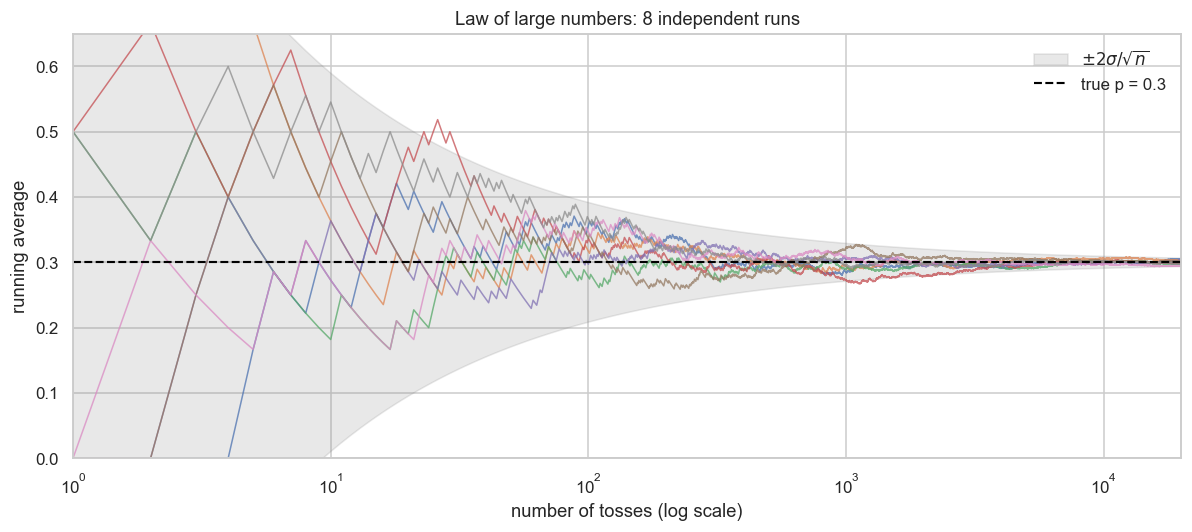

In [23]:

fig, ax = plt.subplots(figsize=(11, 5))
for run in running_mean:
    ax.plot(run, lw=1, alpha=0.75)

# The +/- 2 sigma / sqrt(n) envelope. For a Bernoulli, sigma^2 = p(1-p).
# This is the 1/sqrt(n) rate from point 3 above, drawn.
ns = np.arange(1, n_max + 1)
band = 2 * np.sqrt(p_true * (1 - p_true) / ns)
ax.fill_between(ns, p_true - band, p_true + band, color="grey", alpha=0.18,
                label=r"$\pm 2\sigma/\sqrt{n}$")
ax.axhline(p_true, color="black", lw=1.4, ls="--", label=f"true p = {p_true}")

# Log x-axis: on a linear one, all the drama would be squashed into the
# leftmost 1% of the plot.
ax.set(xscale="log", xlim=(1, n_max), ylim=(0, 0.65),
       xlabel="number of tosses (log scale)", ylabel="running average",
       title="Law of large numbers: 8 independent runs")
ax.legend(frameon=False)
fig.tight_layout()

# print("after     4 tosses, the 8 runs sit at:", running_mean[:, 4].round(2))
print("after     10 tosses, the 8 runs sit at:", running_mean[:, 9].round(2))
print("after 20,000 tosses, the 8 runs sit at:", running_mean[:, -1].round(3))

A note on the plot itself: the x-axis is logarithmic. On a linear axis, all of
the interesting behaviour would be compressed into the left 1% and the other
99% would be a flat line. **A log scale is the default choice for data that
spans several orders of magnitude** — we come back to this in block 5.

And that grey funnel: its width shrinks like $1/\sqrt{n}$. To halve it you have
to go four times further right. That is exactly why an A/B test with 1000 users
usually proves nothing.

## 3.2 The central limit theorem

### Theory

Under the same assumptions plus $\mathrm{Var}(X) = \sigma^2 < \infty$:

$$\frac{\bar{X}_n - \mu}{\sigma/\sqrt{n}} \;\xrightarrow{d}\; \mathcal{N}(0, 1)$$

The distribution of the sample mean — once standardised — tends to a normal,
**no matter what the original distribution was**. The base distribution can be
exponential, Bernoulli, uniform or something entirely strange.

The law of large numbers tells you *where* the mean goes; the CLT tells you
**what shape it has and how much error to expect** on the way. That is why the
confidence interval $\bar{x} \pm 1.96\, s/\sqrt{n}$ works on data that looks
nothing like a normal distribution.

### Know its limits

- **That "$n \ge 30$" rule is folklore.** For a symmetric distribution $n=5$ is
  plenty; for a heavily skewed one (order value, income, duration) even $n=300$
  may not be enough. The skew of the *base* distribution is what decides.
- **No finite variance, no theorem.** For Cauchy or heavy-tailed distributions
  with $\alpha \le 2$, the CLT does not hold.
- **Independence is required.** Correlated time-series data has an effective
  $n$ far smaller than its row count.

Below we start from an **exponential** distribution, because it is completely
asymmetric, which makes the effect much more striking.

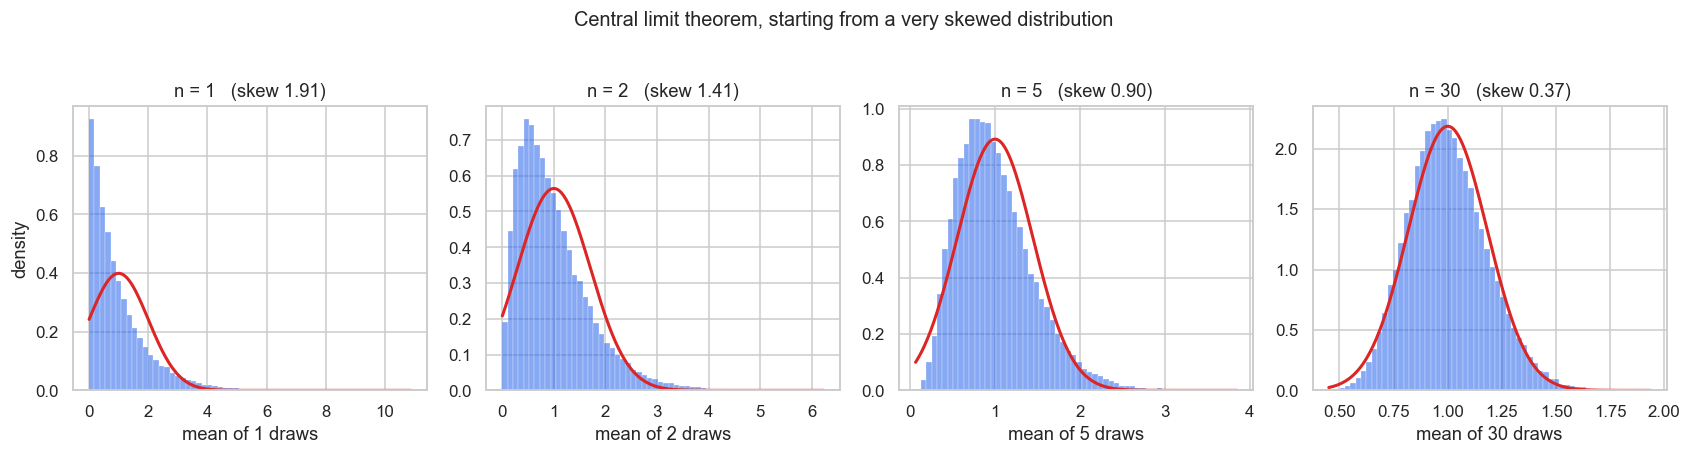

In [24]:
n_sim = 40_000
sample_sizes = [1, 2, 5, 30]

fig, axes = plt.subplots(1, len(sample_sizes), figsize=(15.5, len(sample_sizes)))

for ax, k in zip(axes, sample_sizes):
    # Exponential(1): mean 1, sd 1, and violently right-skewed. Draw
    # (n_sim, k) at once and average along axis 1 -> n_sim sample means.
    means = rng.exponential(scale=1.0, size=(n_sim, k)).mean(axis=1)

    # density=True so the histogram is comparable to a pdf on the same axes.
    ax.hist(means, bins=60, density=True, color="#2563eb", alpha=0.55,
            edgecolor="white", linewidth=0.3)

    # The normal the CLT promises: same mean, sd shrunk by sqrt(k).
    grid = np.linspace(means.min(), means.max(), 300)
    sd = 1.0 / np.sqrt(k)
    pdf = np.exp(-0.5 * ((grid - 1.0) / sd) ** 2) / (sd * np.sqrt(2 * np.pi))
    ax.plot(grid, pdf, color="#dc2626", lw=2)

    # Third standardised moment: 2.0 for the exponential, 0 for a normal.
    skew = ((means - means.mean()) ** 3).mean() / means.std() ** 3
    ax.set(title=f"n = {k}   (skew {skew:.2f})", xlabel=f"mean of {k} draws")
    ax.set_ylabel("density" if k == 1 else "")

fig.suptitle("Central limit theorem, starting from a very skewed distribution",
             fontsize=13, y=1.03)
fig.tight_layout()

From `n=1` — which is the exponential itself, with a skew close to 2 (the
theoretical value is exactly 2) — to `n=30`, where the skew is down to about
0.4 and the red curve sits on top of the histogram. Nobody told the exponential
distribution to become normal; that happens purely from averaging.

The sentence worth writing down: **the CLT is why classical statistics works on
non-normal data.** But do not trust `n = 30` — compute the skew of your own
data.

## 3.3 MLE: maximising the likelihood

### Theory

We have a biased coin with unknown $\mathbb{P}(\text{heads}) = p$. We toss it
$n$ times and see $k$ heads. The likelihood function is the probability of
seeing *exactly this* data given $p$:

$$L(p) = p^{k}(1-p)^{n-k}$$

Take the log — it turns products into sums and prevents numerical underflow,
and since $\log$ is increasing it does not move the location of the maximum:

$$\ell(p) = k\log p + (n-k)\log(1-p)$$

Differentiate and set to zero:

$$\ell'(p) = \frac{k}{p} - \frac{n-k}{1-p} = 0 \;\Longrightarrow\; \hat{p}_{\text{MLE}} = \frac{k}{n}$$

The answer is what your intuition already said. Now let's find the same thing
with code, without knowing how to differentiate.

### Why this section matters for the rest of the bootcamp

Nearly every loss function you meet in the next nine weeks is a **negative
log-likelihood**:

| Loss | Distributional assumption | Where |
|---|---|---|
| MSE | Gaussian error | regression, week 3 |
| Cross-entropy | Bernoulli / categorical | classification, weeks 3 and 4 |
| MAE | Laplace error | when the data has heavy outliers |

So "minimising the loss" and "maximising the likelihood" are two names for the
same job. Internalise that and week 4 gets a lot easier.

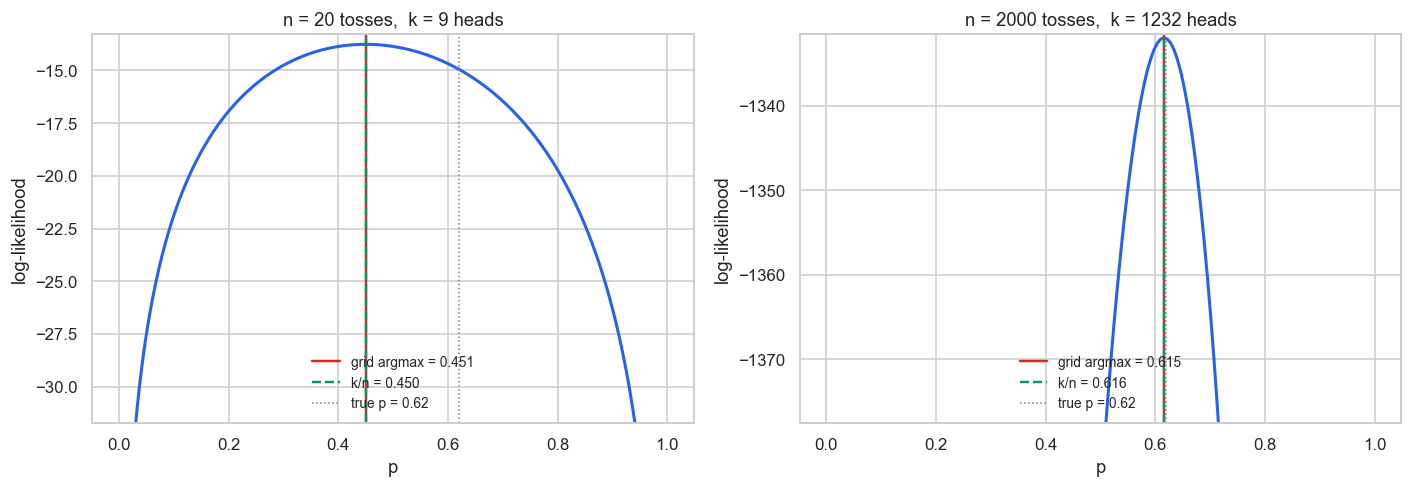

In [25]:
p_true = 0.62
grid = np.linspace(0.001, 0.999, 500)     # candidate values of p to score

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

# Same experiment at two sample sizes, to see what more data buys us.
for ax, n in [(axes[0], 20), (axes[1], 2_000)]:
    data = rng.random(n) < p_true         # n tosses of the biased coin
    k = data.sum()                        # heads observed

    # The log-likelihood, evaluated at all 500 candidates at once. No calculus.
    loglik = k * np.log(grid) + (n - k) * np.log(1 - grid)
    p_hat_grid = grid[loglik.argmax()]    # argmax gives the index, not the value

    ax.plot(grid, loglik, color="#2563eb", lw=2)
    ax.axvline(p_hat_grid, color="#dc2626", lw=1.6,
               label=f"grid argmax = {p_hat_grid:.3f}")
    ax.axvline(k / n, color="#059669", lw=1.6, ls="--",
               label=f"k/n = {k / n:.3f}")
    ax.axvline(p_true, color="grey", lw=1, ls=":", label=f"true p = {p_true}")
    # Clip the y-range to the interesting part; the curve dives to -inf at the
    # edges and would flatten everything else.
    ax.set(xlabel="p", ylabel="log-likelihood",
           title=f"n = {n} tosses,  k = {k} heads",
           ylim=(loglik.max() - 6 * np.log(n), loglik.max() + 0.5))
    ax.legend(frameon=False, fontsize=9, loc="lower center")

fig.tight_layout()

Three things in that plot:

1. **The peak found on the grid lands exactly on $k/n$.** This morning's maths
   and this afternoon's code are the same thing. Even if you did not know the
   derivative, the grid would have given you the answer.

2. **With larger $n$ the peak gets sharper.** More data means less
   uncertainty. The curvature of this curve at its peak has a name — **Fisher
   information** — and its inverse is the variance of your estimator. It is the
   same $1/\sqrt{n}$ from block 3.1, seen from another angle.

3. **And look at the actual numbers:** with 20 tosses the estimate landed on
   0.45 while the true $p$ is 0.62. MLE is not magic; it is *the best guess
   given this data*. The width of that peak is telling you precisely that — the
   left-hand curve is effectively saying "anything between 0.3 and 0.6 is
   consistent with what you saw". Report only the 0.45 and not the width, and
   your report claims more than you know.

The grid method is of course a toy: two parameters means 500×500 points, and
ten parameters is uncomputable. In week 4 you climb this same peak with
**gradients**, which does work in high dimensions. The idea is identical; only
the route to the top changes.

## 3.4 An interview question: a fair choice from a biased coin

> You have a coin that comes up heads with probability $p$. You **do not know**
> $p$, only that $p \ne 0.5$. Design an experiment using only this coin that
> picks one of two people with exactly equal probability.

Think about it for a moment. (It lands better if you work it out with the
person next to you.)

### The answer

Toss the coin **twice**:

| Outcome | Probability | Decision |
|---|---|---|
| heads, tails | $p(1-p)$ | person one |
| tails, heads | $(1-p)p$ | person two |
| heads, heads | $p^2$ | discard and start over |
| tails, tails | $(1-p)^2$ | discard and start over |

The entire trick is one line: $p(1-p) = (1-p)p$. Those two are **always**
equal, for any $p$. So conditional on the pair being decisive:

$$\mathbb{P}(\text{HT} \mid \text{HT or TH}) = \frac{p(1-p)}{2p(1-p)} = \frac{1}{2}$$

And this answer **does not depend on $p$** — you never need to know or estimate
it. This is von Neumann's trick (1951) and it is genuinely used in hardware
random number generators, where the noise source is biased and its bias drifts
with temperature.

### What does it cost?

The probability that a given pair is decisive is $2p(1-p)$. The number of pairs
needed is geometrically distributed, so:

$$\mathbb{E}[\text{pairs}] = \frac{1}{2p(1-p)}, \qquad
\mathbb{E}[\text{tosses}] = \frac{2}{2p(1-p)} = \frac{1}{p(1-p)}$$

For $p = 0.5$ that is 4 tosses (yes — even a fair coin is expensive this way)
and for $p = 0.05$ it is about 21. Fairness is not free.

Let's simulate both claims.

In [26]:
def fair_bit(rng, p):
    """One perfectly fair bit from a coin with P(heads) = p.

    Toss in pairs; HT and TH are equally likely for any p, so use those and
    throw away HH and TT. Returns (bit, number_of_tosses_used).
    """
    tosses = 0
    while True:
        first = rng.random() < p
        second = rng.random() < p
        tosses += 2
        if first != second:          # HT or TH: decisive
            return int(first), tosses
        # HH or TT: no information about which person, so start the pair over


n_draws = 30_000
rows = []

for p in (0.50, 0.30, 0.10, 0.05):
    # zip(*...) transposes the list of (bit, cost) pairs into two tuples.
    bits, costs = zip(*(fair_bit(rng, p) for _ in range(n_draws)))

    # bits = []
    # costs = []
    # for _ in range(n_draws):
    #     bit, cost = fair_bit(rng, p)
    #     bits.append(bit)
    #     costs.append(cost)
    #     bits = np.array(bits)

    # Standard error of a proportion under the claim that it really is 0.5.
    se = np.sqrt(0.25 / n_draws)
    rows.append({
        "p": p,
        "P(bit=1)": np.mean(bits),
        "+/- 2 SE": 2 * se,
        "mean tosses": np.mean(costs),
        "theory 1/(p(1-p))": 1 / (p * (1 - p)),
    })

pd.DataFrame(rows).round(4)

,p,P(bit=1),+/- 2 SE,mean tosses,theory 1/(p(1-p))
0,0.50,0.5014,0.0058,4.0100,4.0000
1,0.30,0.4974,0.0058,4.7645,4.7619
2,0.10,0.5018,0.0058,11.1397,11.1111
3,0.05,0.4998,0.0058,20.9745,21.0526


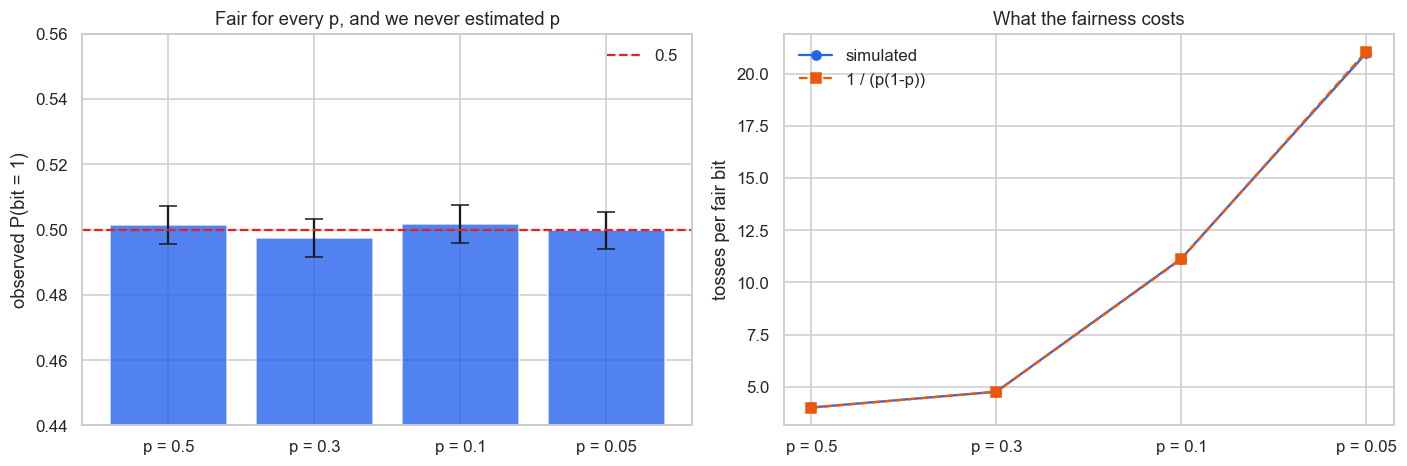

In [27]:
result = pd.DataFrame(rows)

fig, (ax_fair, ax_cost) = plt.subplots(1, 2, figsize=(13, 4.4))

x = np.arange(len(result))

# Left: is it actually fair? Error bars are +/- 2 SE, so if 0.5 falls inside
# them we have no evidence against fairness.
ax_fair.bar(x, result["P(bit=1)"], yerr=result["+/- 2 SE"], capsize=6,
            color="#2563eb", alpha=0.8)
ax_fair.axhline(0.5, color="#dc2626", ls="--", lw=1.5, label="0.5")
ax_fair.set(xticks=x, xticklabels=[f"p = {p}" for p in result["p"]],
            ylim=(0.44, 0.56), ylabel="observed P(bit = 1)",
            title="Fair for every p, and we never estimated p")
ax_fair.legend(frameon=False)

# Right: simulation against the closed-form cost.
ax_cost.plot(x, result["mean tosses"], "o-", color="#2563eb", label="simulated")
ax_cost.plot(x, result["theory 1/(p(1-p))"], "s--", color="#ea580c",
             label="1 / (p(1-p))")
ax_cost.set(xticks=x, xticklabels=[f"p = {p}" for p in result["p"]],
            ylabel="tosses per fair bit", title="What the fairness costs")
ax_cost.legend(frameon=False)

fig.tight_layout()

All four bars sit on 0.5 with the error bar covering it — and we never once
estimated $p$. The cost came out exactly at $1/(p(1-p))$.

If you want to go further: this method is not optimal. The theoretical limit is
the entropy of the source ($H(p)$ bits per toss), and *randomness extractors*
such as Elias's or Peres's algorithms get close to that limit. Entropy is the
same quantity Shamim mentioned this morning.

### Bonus exercise — a uniform number from 1 to 7 using one six-sided die

You have one fair six-sided die. Write a function that returns an integer from
1 to 7 such that all seven values have **exactly** probability $1/7$.

Some approaches that do **not** work, and it is worth understanding why:
- Sum of two dice (2 to 12): not uniform — 7 is six times as likely as 2.
- `(d1 + d2) % 7 + 1`: the sum is not uniform, so neither is its remainder.
- Rolling until you get a 7: the die never shows 7.

Hints:
1. Roll twice. How many equally likely outcomes do you have?
2. That number is not divisible by 7 — but the number **one less** than it is.
   $35 = 5 \times 7$.
3. So reject one of the outcomes and split the rest into 7 equal groups. The
   "reject and retry" idea is exactly von Neumann's idea from the question
   above.
4. Second question: how many rolls does it take on average? Work it out, then
   check it against the simulation.

In [28]:
def rand7_from_d6(rng):
    """Return an integer in 1..7, each with probability exactly 1/7.

    You may only get randomness from rng.integers(1, 7) -- one fair d6 roll.
    """
    # TODO: your turn. Roll in pairs and reject the leftover outcome.
    raise NotImplementedError


def check_rand7(fn, n=200_000):
    """Run the candidate many times and see whether it is really uniform.

    Randomness bugs do not raise; they show up as a small, consistent bias.
    Only a large sample makes that visible -- hence n = 200,000.
    """
    try:
        draws = np.array([fn(rng) for _ in range(n)])
    except NotImplementedError:
        print("rand7_from_d6 is still a TODO -- your turn.")
        return

    # bincount counts occurrences of 0..7; [1:] drops the unused zero slot.
    counts = np.bincount(draws, minlength=8)[1:]
    share = counts / n
    worst = np.abs(share - 1 / 7).max()
    print("counts        :", counts)
    print("shares        :", share.round(4))
    print(f"target        : {1 / 7:.4f}")
    print(f"worst deviation: {worst:.4f}   (expect < 0.003 at n = {n:,})")

    fig, ax = plt.subplots(figsize=(7.5, 3.6))
    ax.bar(np.arange(1, 8), share, color="#2563eb", alpha=0.8)
    ax.axhline(1 / 7, color="#dc2626", ls="--", lw=1.5, label="1/7")
    ax.set(xlabel="value", ylabel="observed share", ylim=(0, 0.2),
           title=f"rand7_from_d6 over {n:,} draws")
    ax.legend(frameon=False)
    fig.tight_layout()


check_rand7(rand7_from_d6)

rand7_from_d6 is still a TODO -- your turn.


---

# Block 4 — pandas on one page

Like block 1, this is **reference** rather than lecture. NumPy is great when
all your data is one type and has no names. Real data is not like that: columns
have names, mixed types, missing values, and have to be joined across files.
That is what pandas is for.

The dataset here is synthetic but its shape is real: quick-commerce orders from
four dark stores. The same dataset is used for the EDA walkthrough in notebook
02.

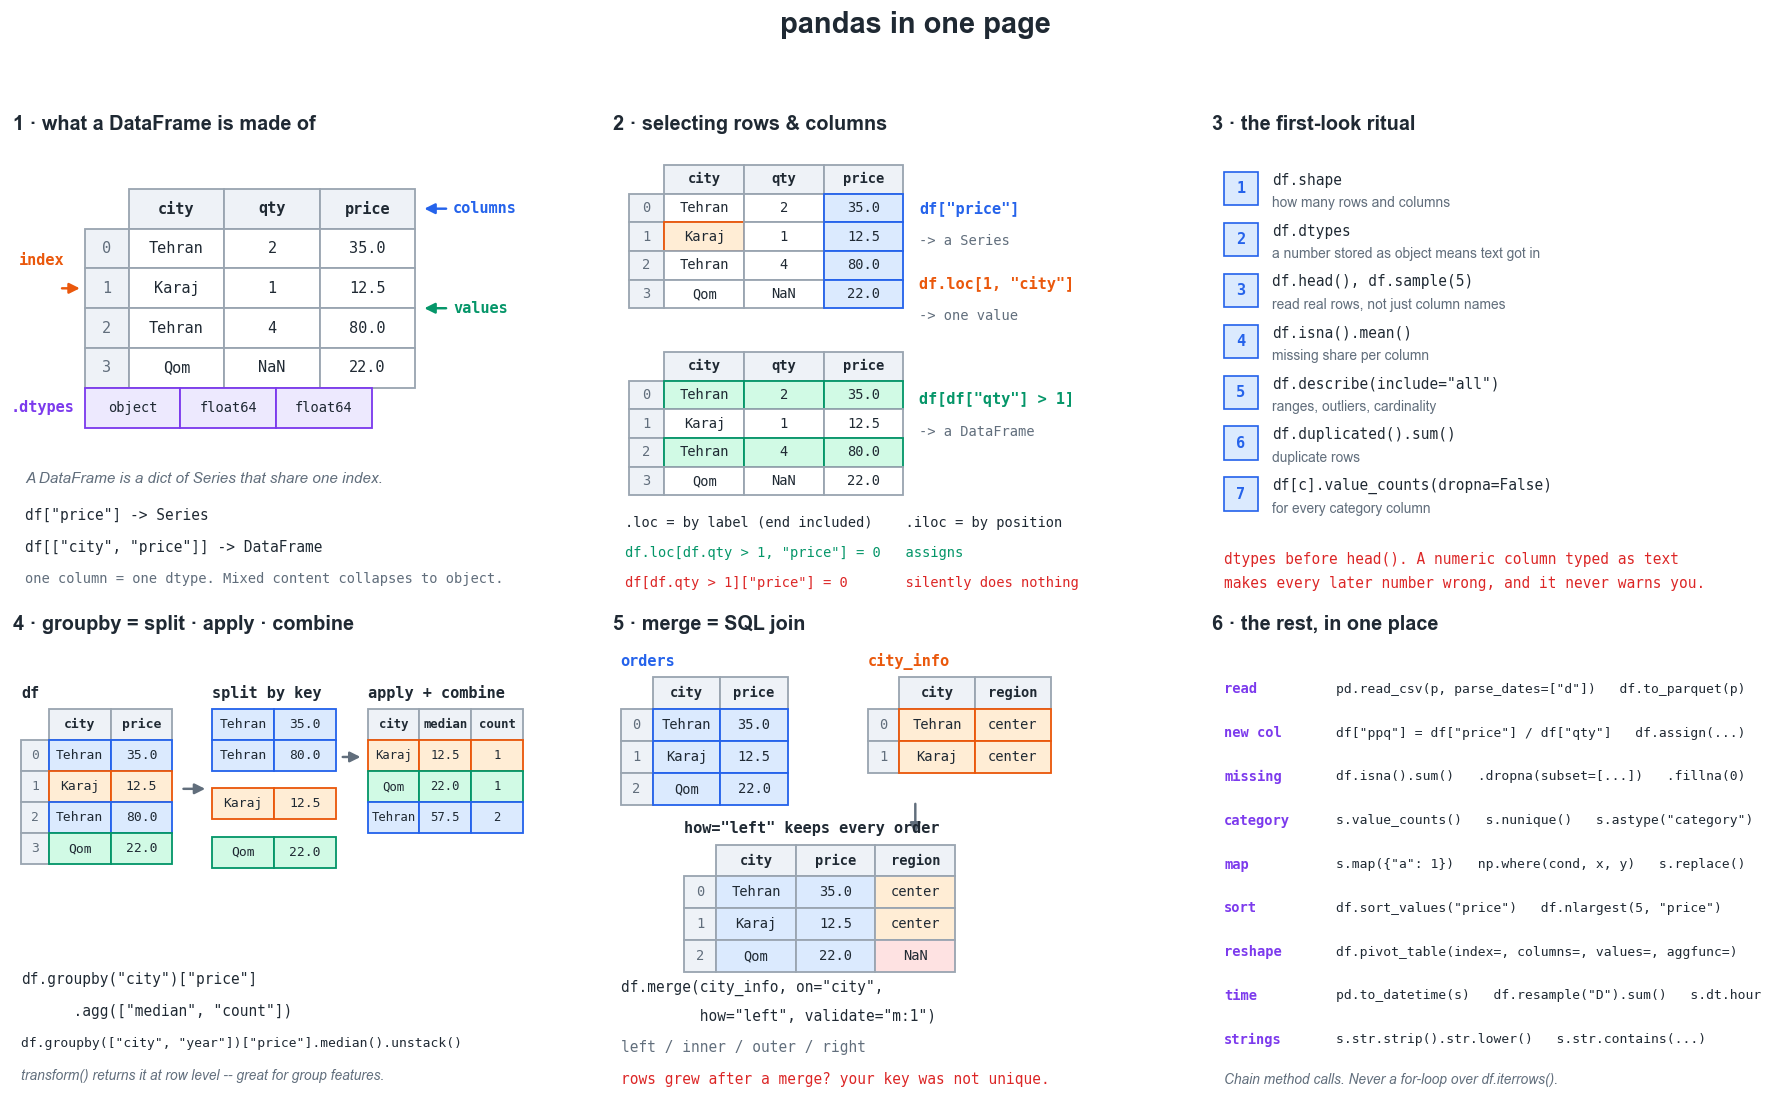

In [29]:
pandas_cheatsheet();   # also in assets/pandas_cheatsheet.png

### 4.1 The first-look ritual

**Always `dtypes` before `head()`.** `head()` is pretty and gives you false
comfort; `dtypes` tells you which of your later calculations will be silently
wrong.

In [30]:
# Deliberately reading it the naive way first -- no parse_dates, no dtype spec.
orders_raw = pd.read_csv(DATA / "qcommerce_orders.csv")

print("shape:", orders_raw.shape, "\n")
print(orders_raw.dtypes, "\n")
orders_raw.head()

shape: (244, 9) 

order_id                int64
order_time             object
store                  object
courier_type           object
basket_size             int64
basket_value_toman      int64
picking_minutes       float64
delivery_minutes      float64
rating                float64
dtype: object 



,order_id,order_time,store,courier_type,basket_size,basket_value_toman,picking_minutes,delivery_minutes,rating
0,100144,2025-08-02 10:46:00,Vakilabad,bicycle,5,735000,6.5,18.6,3.0
1,100004,2025-08-02 12:14:00,Saadatabad,Motorcycle,7,971000,9.2,12.5,5.0
2,100114,2025-08-02 13:02:00,Gohardasht,motorcycle,3,304000,5.8,14.5,5.0
3,100159,2025-08-02 13:15:00,Saadatabad,bicycle,1,116000,2.9,11.2,5.0
4,100157,2025-08-02 13:18:00,Punak,motorcycle,4,497000,6.0,16.4,NaN


First thing found: `order_time` has dtype `object`, i.e. strings. Until it is
converted to `datetime` you cannot get the hour, the weekday, or a correct
sort — and sorting dates as strings fails silently. `parse_dates` fixes it.

The rest of the ritual:

In [31]:
# Sorted so the worst column is at the top -- you always want the ranking,
# not an unordered list.
print("missing share per column:")
print(orders_raw.isna().mean().sort_values(ascending=False).round(3), "\n")

print("duplicated rows:", orders_raw.duplicated().sum(), "\n")

# dropna=False so a NaN category shows up as its own row instead of vanishing.
print("courier_type values:")
print(orders_raw["courier_type"].value_counts(dropna=False), "\n")

# describe() is where impossible values surface: check min and max, not mean.
orders_raw.describe().round(1)

missing share per column:
rating                0.328
order_id              0.000
order_time            0.000
store                 0.000
courier_type          0.000
basket_size           0.000
basket_value_toman    0.000
picking_minutes       0.000
delivery_minutes      0.000
dtype: float64 

duplicated rows: 4 

courier_type values:
courier_type
motorcycle     162
bicycle         56
Motorcycle      20
Bicycle          6
Name: count, dtype: int64 



,order_id,basket_size,basket_value_toman,picking_minutes,delivery_minutes,rating
count,244.0,244.0,244.0,244.0,244.0,164.0
mean,100121.3,4.3,580401.6,7.3,17.3,3.9
std,69.4,2.0,386433.7,2.3,6.5,0.9
min,100001.0,1.0,61000.0,2.9,-1.0,1.0
25%,100061.8,3.0,304750.0,5.8,13.7,3.0
50%,100121.5,4.0,479500.0,6.9,16.2,4.0
75%,100180.2,5.0,736250.0,8.5,19.3,4.2
max,100240.0,12.0,2425000.0,15.7,53.1,5.0


Three minutes of looking, four problems:

| # | Finding | Why it matters |
|---|---|---|
| 1 | `order_time` is a string | no time operation is possible |
| 2 | `courier_type` has four values, not two | `groupby` makes four groups and splits your statistics |
| 3 | `rating` is about a third missing | `mean()` silently drops the NaNs — so it is the mean *of the people who rated* |
| 4 | `delivery_minutes` has a negative minimum | negative delivery time does not exist; one row is broken |

Plus duplicated rows. **None of these raise an error** — which is exactly what
makes them dangerous.

In [32]:
orders = (
    pd.read_csv(DATA / "qcommerce_orders.csv", parse_dates=["order_time"])
      .drop_duplicates()
      # "Motorcycle " and "motorcycle" are the same courier arriving from two
      # different forms. strip() kills the trailing space, lower() the case.
      .assign(courier_type=lambda d: d["courier_type"].str.strip().str.lower())
)

# A negative delivery time is not an outlier to be winsorised, it is a broken
# row. Drop it -- but say out loud how many rows that cost.
bad = orders["delivery_minutes"] <= 0
print(f"dropping {bad.sum()} row(s) with impossible delivery time")
orders = orders.loc[~bad].reset_index(drop=True)

print("shape after cleaning:", orders.shape)
print("courier types:", orders["courier_type"].unique())
print("order_time dtype:", orders["order_time"].dtype)

dropping 1 row(s) with impossible delivery time
shape after cleaning: (239, 9)
courier types: ['bicycle' 'motorcycle']
order_time dtype: datetime64[ns]


Notice we made no decision about `rating`, and that is deliberate. That missing
third is **not random** — in notebook 02 I show you that the rated orders are
systematically slower, because satisfied customers do not leave feedback and
annoyed ones do. So filling it with the mean takes a bias and spreads it across
the whole dataset.

The general rule, worth writing down: **before you fill a missing value, ask
why it is missing.**

### 4.2 merge — and the only two professional habits you need

In [33]:
stores = pd.read_csv(DATA / "qcommerce_stores.csv")
print(stores, "\n")

rows_before = len(orders)

# validate="m:1" asserts: many orders, exactly one row per store. If the
# right-hand key is not unique, pandas raises instead of silently multiplying
# your rows. how="left" keeps every order even if its store is missing.
orders = orders.merge(stores, on="store", how="left", validate="m:1")

print(f"rows: {rows_before} -> {len(orders)}   (must be identical)")
print("unmatched stores:", orders["city"].isna().sum())

        store     city region  opened_year  area_m2
0  Saadatabad   Tehran  north         2022      310
1       Punak   Tehran   west         2023      250
2  Gohardasht    Karaj   west         2024      190
3   Vakilabad  Mashhad   east         2023      275 

rows: 239 -> 239   (must be identical)
unmatched stores: 0


Make these two a habit:

1. **`validate="m:1"` on every `merge`.** Without it, a duplicated key on the
   right silently duplicates your rows and you find out a week later when your
   revenue total has doubled.
2. **Print the row count after every `merge`.** Row count grew ⇒ non-unique
   key. Row count shrank with `how="inner"` ⇒ data you dropped without
   noticing.

### 4.3 New columns, groupby, pivot

In [34]:
# assign with lambdas lets each new column see the ones defined above it in
# the same call, and returns a new frame instead of mutating in place.
orders = orders.assign(
    total_minutes=lambda d: d["picking_minutes"] + d["delivery_minutes"],
    value_per_item=lambda d: d["basket_value_toman"] / d["basket_size"],
    # .dt is the accessor for datetime columns -- only available because we
    # used parse_dates above.
    hour=lambda d: d["order_time"].dt.hour,
    is_peak=lambda d: d["order_time"].dt.hour >= 19,
)

orders[["store", "city", "courier_type", "basket_size",
        "delivery_minutes", "total_minutes", "rating"]].head()

,store,city,courier_type,basket_size,delivery_minutes,total_minutes,rating
0,Vakilabad,Mashhad,bicycle,5,18.6,25.1,3.0
1,Saadatabad,Tehran,motorcycle,7,12.5,21.7,5.0
2,Gohardasht,Karaj,motorcycle,3,14.5,20.3,5.0
3,Saadatabad,Tehran,bicycle,1,11.2,14.1,5.0
4,Punak,Tehran,motorcycle,4,16.4,22.4,NaN


In [35]:
# Named aggregation: output_name=(source_column, function). You choose the
# column names, so the result is readable without a second look.
by_store = orders.groupby("store").agg(
    orders=("order_id", "size"),
    median_delivery=("delivery_minutes", "median"),
    p90_delivery=("delivery_minutes", lambda s: s.quantile(0.90)),
    mean_rating=("rating", "mean"),
    rated_share=("rating", lambda s: s.notna().mean()),
).sort_values("median_delivery").round(2)

by_store

,orders,median_delivery,p90_delivery,mean_rating,rated_share
store,,,,,
Saadatabad,88,14.05,23.56,4.08,0.56
Vakilabad,62,16.40,21.32,3.95,0.68
Punak,54,16.45,22.35,3.72,0.74
Gohardasht,35,20.00,25.96,3.62,0.83


Read the last two columns together: `mean_rating` is the mean **among those who
rated**, and `rated_share` tells you what fraction that was. Separating those
two is the difference between an honest report and a misleading one.

I put `p90` next to `median` because in operations the **tail** is what
matters, not the middle. For the customer who waited 40 minutes, "our median is
12 minutes" is not an answer.

In [36]:
# pivot_table = groupby on two keys, then unstack one of them into columns.
# Same numbers as groupby(["store", "courier_type"]), better shaped for reading.
pivot = orders.pivot_table(index="store", columns="courier_type",
                           values="delivery_minutes", aggfunc="median")
pivot.round(1)

courier_type,bicycle,motorcycle
store,,
Gohardasht,20.8,20.0
Punak,18.5,15.7
Saadatabad,15.9,13.2
Vakilabad,18.6,15.0


### 4.4 The warning everybody ignores

Let's open up `SettingWithCopyWarning` once, because it marks the line between
"code that works" and "code you think works".

In [37]:
demo = orders.head(20).copy()

# Wrong: df[mask] hands you a NEW object (chained indexing). You assign into
# that temporary and it is thrown away -- pandas warns, then does nothing.
demo[demo["basket_size"] > 5]["flag"] = 1
print("did the wrong version create a column?", "flag" in demo.columns)

# Right: a single .loc[rows, column] call, so pandas knows the assignment
# target is `demo` itself.
demo.loc[demo["basket_size"] > 5, "flag"] = 1
print("did .loc work?                       ", "flag" in demo.columns,
      "| rows flagged:", int(demo["flag"].notna().sum()))

did the wrong version create a column? False
did .loc work?                        True | rows flagged: 3


/var/folders/5q/r8mcn8fx4w71k7gbbl4xr6jw0000gp/T/ipykernel_2408/709975879.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  demo[demo["basket_size"] > 5]["flag"] = 1


The rule: **whenever you assign into a subset, use `.loc`.** And if you are
deliberately taking a slice of a frame to work on separately, call `.copy()` so
that the intent is explicit.

---

## ☕ 2-minute break

After the break: plots.

---

# Block 5 — matplotlib and seaborn, only as much as you need

Learn one pattern and stay loyal to it:

```python
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(x, y)
ax.set(xlabel="...", ylabel="...", title="...")
```

The global `plt.plot()` is fine for a quick look, but it carries hidden state
and will fight you the moment your figure has two panels. `fig, ax` gives you
control from day one.

**What does seaborn add?** Three things: better visual defaults, `hue`/`col`
for splitting data on a categorical variable, and plots that compute their own
statistics (`boxplot`, `histplot` with `kde`, `regplot`, `heatmap`). It takes a
DataFrame directly. Underneath it is still matplotlib, which is why you hand
seaborn an `ax` and then keep going with matplotlib on that same `ax`.

In practice **six plots** cover 90% of your work:

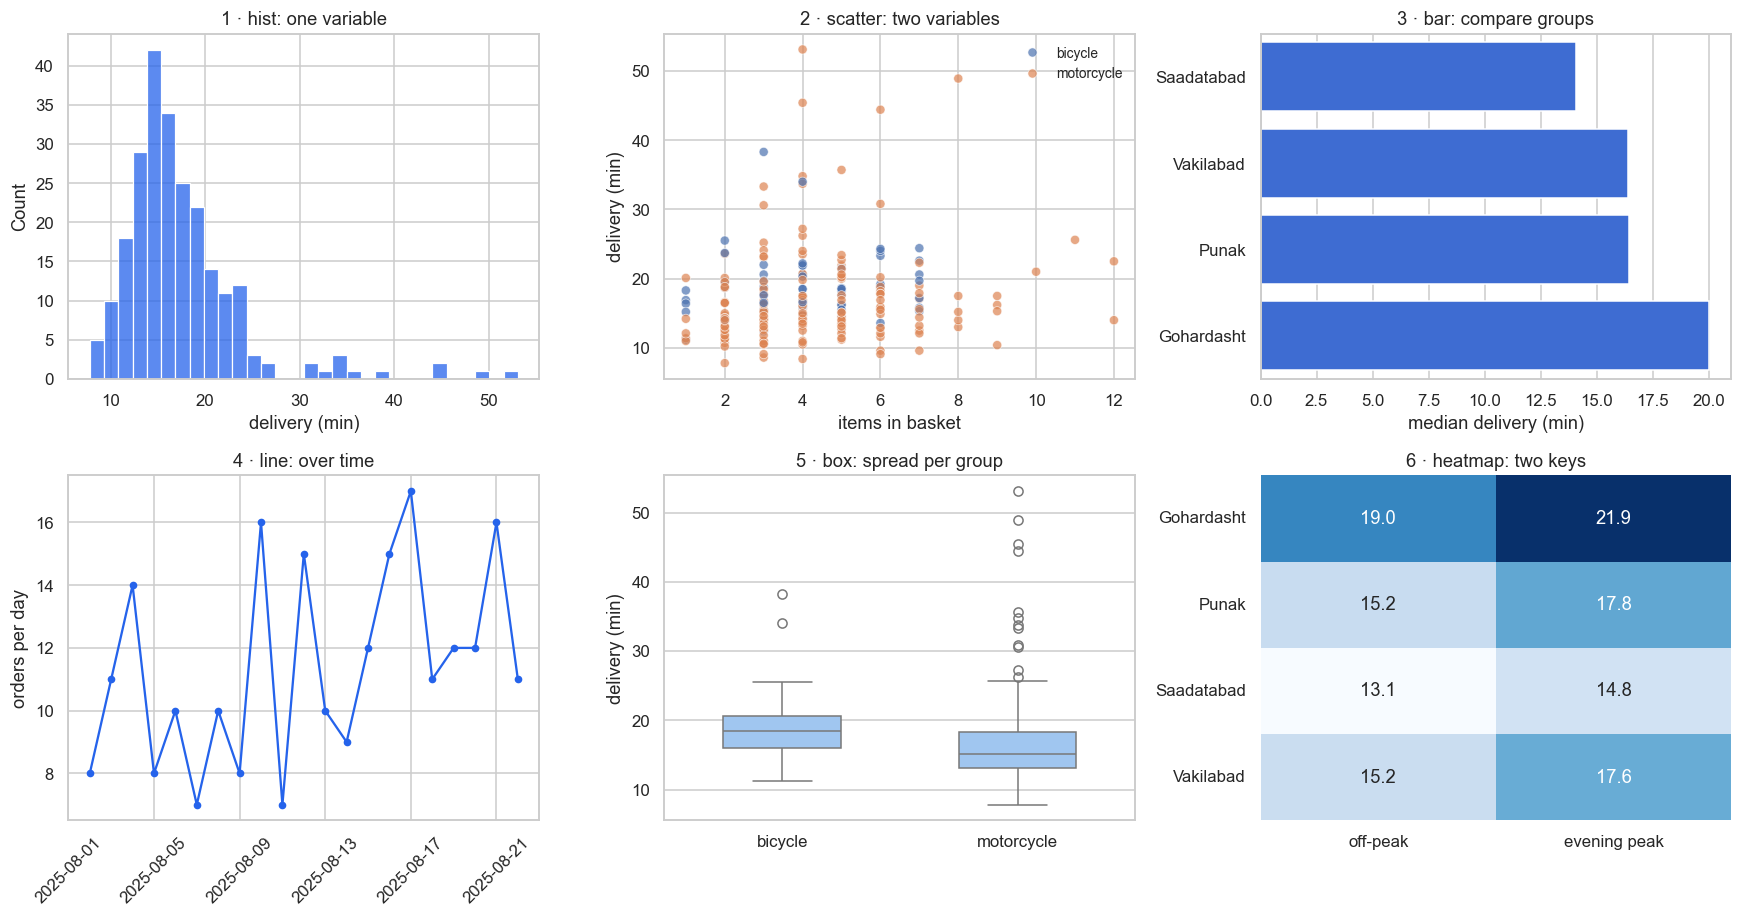

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8.5))
ax1, ax2, ax3, ax4, ax5, ax6 = axes.ravel()

# 1. distribution of one variable -> "what is normal, and how long is the tail?"
sns.histplot(orders, x="delivery_minutes", bins=30, ax=ax1, color="#2563eb")
ax1.set(title="1 · hist: one variable", xlabel="delivery (min)")

# 2. relationship between two -> "does A move with B?"
#    alpha < 1 so overlapping points show up as darker regions.
sns.scatterplot(orders, x="basket_size", y="delivery_minutes",
                hue="courier_type", alpha=0.7, ax=ax2)
ax2.set(title="2 · scatter: two variables", xlabel="items in basket",
        ylabel="delivery (min)")
ax2.legend(title=None, frameon=False, fontsize=9)

# 3. compare categories. `order` is what stops seaborn sorting alphabetically;
#    by_store is already sorted by median, so the bars carry meaning.
order = by_store.index
sns.barplot(orders, x="delivery_minutes", y="store", order=order,
            estimator="median", errorbar=None, ax=ax3, color="#2563eb")
ax3.set(title="3 · bar: compare groups", xlabel="median delivery (min)", ylabel="")

# 4. change over time. resample("D") needs a datetime index, hence set_index.
daily = orders.set_index("order_time").resample("D").size()
ax4.plot(daily.index, daily.values, marker="o", ms=4, color="#2563eb")
ax4.set(title="4 · line: over time", ylabel="orders per day")
ax4.tick_params(axis="x", rotation=45)

# 5. distribution *within* each category -- a bar chart of means hides this.
sns.boxplot(orders, x="courier_type", y="delivery_minutes", ax=ax5,
            width=0.5, color="#93c5fd")
ax5.set(title="5 · box: spread per group", xlabel="", ylabel="delivery (min)")

# 6. two categorical keys at once. annot=True writes the number in each cell,
#    which a heatmap needs -- colour alone is not readable to that precision.
heat = orders.pivot_table(index="store", columns="is_peak",
                          values="delivery_minutes", aggfunc="median")
heat.columns = ["off-peak", "evening peak"]
sns.heatmap(heat, annot=True, fmt=".1f", cmap="Blues", cbar=False, ax=ax6)
ax6.set(title="6 · heatmap: two keys", xlabel="", ylabel="")
ax6.tick_params(axis="y", rotation=0)

fig.tight_layout()

### Three matters of taste that raise the quality of your project

1. **Every plot says one sentence.** If you cannot say the sentence, you did
   not need the plot. Make the title that sentence, not a list of column names.
2. **Axes always carry a label and a unit.** What does "12" mean? Minutes?
   Toman? Thousands of toman?
3. **Sort your categories; never leave them alphabetical.** The eye goes to
   the longest bar first — make sure that bar means something.

And a fourth rule that is half the job on its own: **plot skewed data on a log
scale.** Basket value, income, population, duration — all skewed.

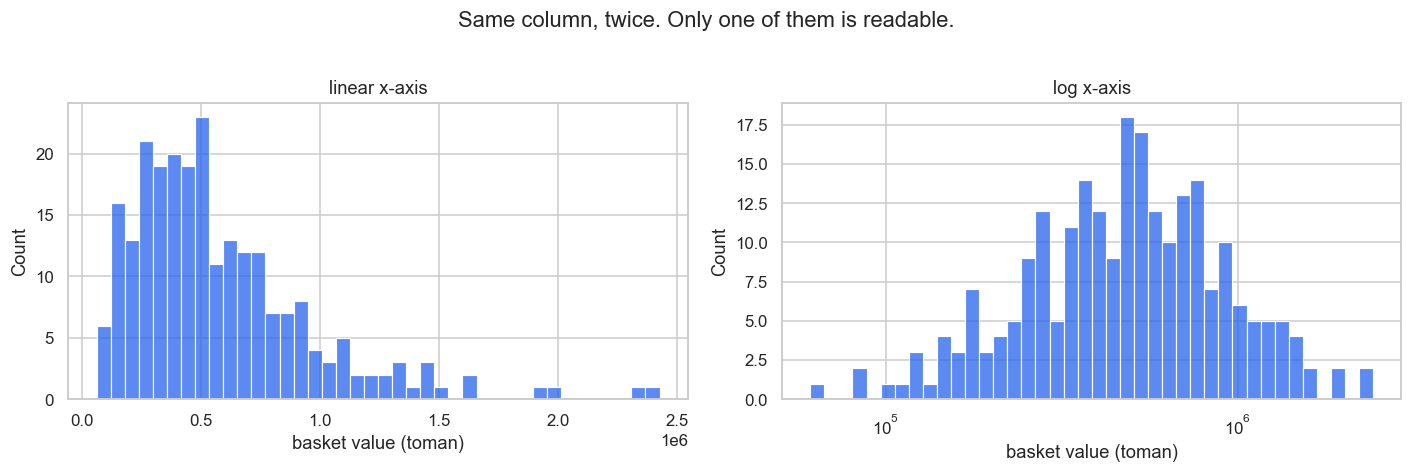

In [39]:
fig, (ax_lin, ax_log) = plt.subplots(1, 2, figsize=(13, 4.2))

# log_scale=(True, False) means: log the x-axis, leave y linear.
for ax, log in [(ax_lin, False), (ax_log, True)]:
    sns.histplot(orders, x="basket_value_toman", bins=40, ax=ax,
                 log_scale=(log, False), color="#2563eb")
    ax.set(title="log x-axis" if log else "linear x-axis",
           xlabel="basket value (toman)")

fig.suptitle("Same column, twice. Only one of them is readable.", y=1.02)
fig.tight_layout()

On the left: one spike and a shapeless tail. On the right: a roughly symmetric
distribution you can actually talk about. The data did not change — only the
axis did.

**A note on Persian text in plots:** matplotlib's default font has no Persian
glyphs, so the characters come out as boxes (and even with the right font, you
need `arabic-reshaper` plus `python-bidi` or the letters arrive disconnected
and reversed). Labels in this notebook are English for that reason. If your
project needs Persian, test it **before** your presentation; hunting for a font
mid-session is the worst possible outcome.

---

# Block 6 — Hand-off to the maths project

The maths project was kicked off at 14:00 today and you start on it tomorrow.
Here is the map:

| For this | Go to | What is ready for you |
|---|---|---|
| loading and cleaning a CSV | block 4 | `read_csv` with `parse_dates`, `drop_duplicates`, the first-look ritual |
| vectorising a formula | blocks 0 and 1 | pairwise distance matrix, broadcasting, `[:, None]` |
| SVD / PCA / dimensionality reduction | block 2 | four-line PCA plus the sklearn comparison |
| any probabilistic claim | block 3 | the simulation pattern: `default_rng` → sample → average → plot |
| plots for the report | block 5 | six plots, the `fig, ax` pattern |

### The two exercises still open

- `row_normalise` in block 1 — vectorise a loop
- `rand7_from_d6` in block 3 — uniform generation by rejection

Solutions get pushed to `01_exercises_solutions.ipynb` after the session. Try
them first; nobody ever became a programmer by reading answers.

### Your next step today

Open `02_data_science_pipeline.ipynb`: the stages of a real data science
project, and where EDA — whose tools you just picked up — actually sits in it.

### Next week

Week 3 takes these same tools through a full scikit-learn pipeline, and then
after lunch there is a whole workshop on every way you can accidentally cheat
yourself (data leakage). That is where you find out how serious I was about
"`dtypes` before `head()`".